# 01 — Exploratory Data Analysis: the Nepanglish labeled corpus

Everything labeled in the harness so far, read straight from the four dataset exports and
profiled on all available CPU cores.

**What this notebook is for.** The corpus is small and expensive, so the questions worth asking
of it are not "what does the data look like" but:

1. **How much is there, and of what?** Hours, episodes, splits, and how far the two pots are from
   their targets.
2. **What did labeling actually do?** The edit rate is the number everything downstream depends
   on — it is the ceiling on how much of the queue can ever be auto-approved.
3. **Is the corpus code-switched enough to be worth building?** CMI at the segment and token level.
4. **Which strata are thin?** The gold pot is meant to span speakers, genres and topics, not just
   accumulate hours.
5. **How good are the three ASR systems on human reference,** overall and where the code-switching
   is dense.
6. **Does cross-ASR disagreement predict a human edit** well enough to gate pseudo-labels?
7. **Does the seed system anchor the annotator?** If it does, the benchmark is contaminated.

**Parallelism.** Every expensive step — JSONL parsing, checksum verification, token profiling,
Levenshtein WER/CER, and the bootstraps — fans out over processes with `joblib`, with the
numeric libraries pinned to one thread per worker so the two layers do not oversubscribe the box.
Each such cell prints its wall time and, where a serial baseline is cheap enough to measure, the
speedup it bought. At 11 hours of audio the absolute times are small — the point of the layout is
that it does not need rewriting when the corpus grows into the ~2,400-hour archive behind it.

**Running it.** The environment is `notebooks/requirements.txt`, deliberately separate from the
backend's — the harness image must not grow a pandas dependency. The data comes from the four
dataset exports:

```bash
python scripts/export_dataset.py --kind all      # writes exports/{analytics,training,gold,error_mining}/

uv venv --python 3.13 notebooks/.venv
VIRTUAL_ENV=notebooks/.venv uv pip install -r notebooks/requirements.txt
notebooks/.venv/bin/python -m ipykernel install --user \
    --name labeling-harness-eda --display-name "labeling-harness (EDA)"
```

**Provenance.** The exports are produced by `scripts/export_dataset.py` and carry a manifest with
the git commit, the label and policy versions, and a SHA-256 per file. Section 2 verifies those
checksums before anything is read, so a stale or truncated export fails loudly here rather than
quietly skewing a number further down.

## 1. Environment and parallel setup

In [1]:
import os

# Pin the numeric libraries to a single thread each *before* numpy is imported. Every heavy step
# below fans out with joblib over processes; letting BLAS and OpenMP fan out again inside each
# worker oversubscribes the machine and makes the parallel version slower than the serial one.
for _var in (
    "OMP_NUM_THREADS",
    "OPENBLAS_NUM_THREADS",
    "MKL_NUM_THREADS",
    "NUMEXPR_NUM_THREADS",
    "VECLIB_MAXIMUM_THREADS",
):
    os.environ.setdefault(_var, "1")

import hashlib
import json
import re
import time
import unicodedata
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats as st
from joblib import Parallel, cpu_count, delayed
from rapidfuzz.distance import Levenshtein

N_JOBS = cpu_count()

#: One reused pool. loky caches its executor, so the workers are spawned once for the whole
#: notebook rather than once per parallel section.
POOL = Parallel(n_jobs=N_JOBS, backend="loky")

pd.set_option("display.width", 130)
pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

_style = "seaborn-v0_8-whitegrid"
plt.style.use(_style if _style in plt.style.available else "default")
plt.rcParams.update({"font.size": 10, "figure.autolayout": True, "figure.dpi": 110})

# Some episode ids are Devanagari and matplotlib does not chain font families per glyph: whichever
# family resolves first renders every character, so a Latin default draws Devanagari as empty
# boxes and a Devanagari font draws Latin as empty boxes. Tick labels are therefore given their
# font one at a time, by script.
_installed = {f.name for f in plt.matplotlib.font_manager.fontManager.ttflist}
DEVA_FONT = next(
    (n for n in ("Noto Sans Devanagari", "Noto Serif Devanagari", "FreeSans") if n in _installed),
    None,
)
DEVANAGARI = re.compile(r"[ऀ-ॿ]")


def script_aware_ticklabels(ax, axis, labels, **kwargs):
    """Set tick labels, switching to a Devanagari face for the ones that need it."""
    setter = ax.set_yticklabels if axis == "y" else ax.set_xticklabels
    texts = setter(labels, **kwargs)
    if DEVA_FONT:
        for text in texts:
            if DEVANAGARI.search(text.get_text()):
                text.set_fontfamily(DEVA_FONT)
    return texts

#: Ordered so a system keeps the same colour in every figure.
SYSTEMS = ["elevenlabs-scribe-v2", "gemini-3.8-flash", "mai-transcribe-2"]
SYS_COLOR = dict(zip(SYSTEMS, ["#2563eb", "#d97706", "#059669"]))
POT_COLOR = {"gold": "#b45309", "train": "#2563eb", "unassigned": "#9ca3af"}

REPO_ROOT = Path("..").resolve() if Path("../exports").is_dir() else Path(".").resolve()
EXPORT_ROOT = REPO_ROOT / "exports"
FIG_DIR = REPO_ROOT / "notebooks" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)


def save_fig(fig, name):
    """Write a figure to notebooks/figures/ and report where it went."""
    path = FIG_DIR / f"eda_{name}.png"
    fig.savefig(path, dpi=150, bbox_inches="tight")
    print(f"  figure -> {path.relative_to(REPO_ROOT)}")


def timed(label, seconds, extra=""):
    """Uniform one-line timing report for the parallel sections."""
    print(f"  [{label}] {seconds:.2f}s{(' — ' + extra) if extra else ''}")


print(f"CPU cores available   : {N_JOBS}")
print(f"joblib backend        : loky, {N_JOBS} worker processes, 1 BLAS thread each")
print(f"repository root       : {REPO_ROOT}")
print(f"export root           : {EXPORT_ROOT}")
print(f"Devanagari face      : {DEVA_FONT or 'NONE INSTALLED — Devanagari labels will not render'}")
print(f"pandas {pd.__version__} / numpy {np.__version__} / matplotlib {plt.matplotlib.__version__}")

CPU cores available   : 16
joblib backend        : loky, 16 worker processes, 1 BLAS thread each
repository root       : /home/sagyam/Projects/labeling-harness
export root           : /home/sagyam/Projects/labeling-harness/exports
Devanagari face      : Noto Sans Devanagari
pandas 3.0.5 / numpy 2.5.3 / matplotlib 3.11.1


## 2. Export provenance and integrity

Four export kinds are written by `scripts/export_dataset.py`, each with a manifest recording the
filters it applied, the git commit that produced it, and a SHA-256 per file. `analytics` is the
superset this notebook works from — every labeled row, including the ones a training export drops,
with per-hypothesis and per-word fields attached.

The checksums are recomputed in parallel and compared. If one disagrees, stop: the numbers below
would be describing a file that is not the one the manifest documents.

In [2]:
KINDS = ["analytics", "training", "gold", "error_mining"]

manifests = {}
for kind in KINDS:
    manifest_path = EXPORT_ROOT / kind / "manifest.json"
    if manifest_path.is_file():
        manifests[kind] = json.loads(manifest_path.read_text(encoding="utf-8"))

if "analytics" not in manifests:
    raise SystemExit(
        "no analytics export found — run:  python scripts/export_dataset.py --kind all"
    )


def sha256_of(path):
    """Stream a file through SHA-256; returns (path, digest) so results can be reordered."""
    digest = hashlib.sha256()
    with open(path, "rb") as handle:
        for block in iter(lambda: handle.read(1 << 20), b""):
            digest.update(block)
    return str(path), digest.hexdigest()


wanted = {}
for kind, manifest in manifests.items():
    for entry in manifest["files"]:
        wanted[str(EXPORT_ROOT / kind / entry["name"])] = (kind, entry["name"], entry["sha256"])

t0 = time.perf_counter()
computed = dict(POOL(delayed(sha256_of)(Path(p)) for p in wanted))
elapsed = time.perf_counter() - t0
total_bytes = sum(Path(p).stat().st_size for p in wanted)
timed("sha256", elapsed, f"{len(wanted)} files, {total_bytes / 1e6:.1f} MB over {N_JOBS} workers")

integrity = pd.DataFrame(
    [
        {
            "kind": kind,
            "file": name,
            "MB": round(Path(path).stat().st_size / 1e6, 2),
            "rows": manifests[kind]["row_count"],
            "sha256_ok": computed[path] == expected,
        }
        for path, (kind, name, expected) in sorted(wanted.items())
    ]
)
assert integrity["sha256_ok"].all(), integrity[~integrity["sha256_ok"]]
display(integrity)

am = manifests["analytics"]
print(f"exported_at           : {am['exported_at']}")
print(f"git commit            : {am['git_commit']}")
print(f"label / policy version: {am['label_version']} / {am['policy_version']}")
print(f"normalization version : {am.get('normalization_version')}")
print(f"import runs behind it : {len(am['import_runs'])}")
print(f"rows by split         : {am['row_counts_by_split']}")
print(f"verification tiers    : {am['verification_tiers_by_split']}")

  [sha256] 0.13s — 4 files, 63.0 MB over 16 workers


,kind,file,MB,rows,sha256_ok
0,analytics,analytics.jsonl,60.0800,3375,True
1,error_mining,error_mining.jsonl,0.0100,5,True
2,gold,gold.jsonl,0.9300,1060,True
3,training,training.jsonl,1.9600,2313,True


exported_at           : 2026-09-07T19:52:27.486628+00:00
git commit            : 63ab2203a8390926f70d62faf13a68a5f6da2cc7
label / policy version: v1 / policy_v1
normalization version : norm-v3
import runs behind it : 20
rows by split         : {'test': 1057, 'train': 2318}
verification tiers    : {'test': {'verified': 1057}, 'train': {'screened': 836, 'verified': 1482}}


## 3. Parallel load

`analytics.jsonl` is one JSON object per labeled segment, each carrying three ASR hypotheses and
their word lists — roughly 350,000 word objects in total, which is what makes a single-threaded
`json.loads` loop the slowest step in the notebook.

The file is split into byte ranges snapped forward to the next newline, one per worker. Each worker
parses its range and **reduces as it goes**: it returns flat segment and hypothesis records plus
concatenated word-duration and word-confidence arrays, never the 350,000 dictionaries themselves.
That keeps the inter-process pickling proportional to the summary, not to the raw file.

In [3]:
ANALYTICS_PATH = EXPORT_ROOT / "analytics" / "analytics.jsonl"


def chunk_bounds(path, n_chunks):
    """Split a file into n byte ranges, each ending on a newline so no record is cut in half."""
    size = path.stat().st_size
    bounds, start = [], 0
    with path.open("rb") as handle:
        for index in range(1, n_chunks):
            handle.seek(size * index // n_chunks)
            handle.readline()
            position = handle.tell()
            if position > start:
                bounds.append((start, position))
                start = position
        if start < size:
            bounds.append((start, size))
    return bounds


def parse_chunk(path, start, end):
    """Parse one byte range of the analytics export into flat, already-reduced records."""
    segments, hypotheses = [], []
    word_dur, word_conf = {}, {}

    with open(path, "rb") as handle:
        handle.seek(start)
        payload = handle.read(end - start)

    for line in payload.splitlines():
        if not line.strip():
            continue
        record = json.loads(line)
        scores = record.get("scores") or {}
        meta = record.get("episode_metadata") or {}
        speakers = meta.get("speakers") or {}
        genders = sorted({s.get("gender") for s in speakers.values() if s.get("gender")})
        ages = sorted({s.get("age_bracket") for s in speakers.values() if s.get("age_bracket")})

        segments.append(
            {
                "segment_id": record["segment_id"],
                "episode_id": record["episode_id"],
                "split": record["split"],
                "pot": record["pot"],
                "disposition": record["disposition"],
                "verification_tier": record["verification_tier"],
                "seed_system_id": record.get("seed_system_id"),
                "start_time": record.get("start_time"),
                "end_time": record.get("end_time"),
                "duration_seconds": record.get("duration_seconds"),
                "text": record.get("text") or "",
                "notes": record.get("notes"),
                "speaker_id": record.get("speaker_id"),
                "code_switch_density": record.get("code_switch_density"),
                "cer_between_hypotheses": scores.get("cer_between_hypotheses"),
                "word_disagreement_rate": scores.get("word_disagreement_rate"),
                "script_conflict_rate": scores.get("script_conflict_rate"),
                "flags": list(scores.get("flags") or []),
                "genre": meta.get("genre"),
                "topic": meta.get("topic"),
                "topic_source": meta.get("topic_source"),
                "n_speakers": len(speakers),
                "gender_mix": "mixed" if len(genders) > 1 else (genders[0] if genders else None),
                "age_mix": "mixed" if len(ages) > 1 else (ages[0] if ages else None),
                "label_version": record.get("label_version"),
                "policy_version": record.get("policy_version"),
            }
        )

        for hypothesis in record.get("hypotheses") or []:
            system = hypothesis["system_id"]
            words = hypothesis.get("words") or []
            durations = [
                w["end"] - w["start"]
                for w in words
                if w.get("start") is not None and w.get("end") is not None
            ]
            confidences = [w["confidence"] for w in words if w.get("confidence") is not None]
            word_dur.setdefault(system, []).extend(durations)
            word_conf.setdefault(system, []).extend(confidences)
            hypotheses.append(
                {
                    "segment_id": record["segment_id"],
                    "system_id": system,
                    "model_id": hypothesis.get("model_id"),
                    "text": hypothesis.get("text") or "",
                    "avg_logprob": hypothesis.get("avg_logprob"),
                    "no_speech_prob": hypothesis.get("no_speech_prob"),
                    "n_words": len(words),
                    # Total time the words themselves cover, for comparison with clip duration:
                    # a large shortfall is the shape of a hypothesis that stopped early.
                    "word_span_seconds": float(sum(durations)),
                    "last_word_end": max((w["end"] for w in words if w.get("end")), default=None),
                    "mean_word_conf": (
                        float(np.mean(confidences)) if confidences else float("nan")
                    ),
                }
            )

    return {
        "segments": segments,
        "hypotheses": hypotheses,
        "word_dur": {k: np.asarray(v, dtype="float32") for k, v in word_dur.items()},
        "word_conf": {k: np.asarray(v, dtype="float32") for k, v in word_conf.items()},
    }


bounds = chunk_bounds(ANALYTICS_PATH, N_JOBS)
t0 = time.perf_counter()
parts = POOL(delayed(parse_chunk)(str(ANALYTICS_PATH), lo, hi) for lo, hi in bounds)
parallel_seconds = time.perf_counter() - t0

t0 = time.perf_counter()
_serial = parse_chunk(str(ANALYTICS_PATH), 0, ANALYTICS_PATH.stat().st_size)
serial_seconds = time.perf_counter() - t0

seg_records = [row for part in parts for row in part["segments"]]
hyp_records = [row for part in parts for row in part["hypotheses"]]
WORD_DUR = {
    system: np.concatenate([p["word_dur"][system] for p in parts if system in p["word_dur"]])
    for system in SYSTEMS
}
WORD_CONF = {
    system: np.concatenate([p["word_conf"][system] for p in parts if system in p["word_conf"]])
    for system in SYSTEMS
}
n_words = sum(len(v) for v in WORD_DUR.values())

assert len(seg_records) == len(_serial["segments"]), "chunking lost or duplicated a record"
timed(
    "load",
    parallel_seconds,
    f"{len(seg_records):,} segments, {len(hyp_records):,} hypotheses, {n_words:,} words "
    f"across {len(bounds)} chunks",
)
print(f"  serial baseline: {serial_seconds:.2f}s  ->  speedup {serial_seconds / parallel_seconds:.1f}x")
del _serial

  [load] 0.08s — 3,375 segments, 10,125 hypotheses, 343,812 words across 16 chunks
  serial baseline: 0.43s  ->  speedup 5.1x


In [4]:
seg = pd.DataFrame(seg_records).set_index("segment_id").sort_index()
hyp = pd.DataFrame(hyp_records).sort_values(["segment_id", "system_id"], ignore_index=True)

seg["is_edited"] = (seg["disposition"] == "edited").astype(int)
seg["is_screened"] = (seg["verification_tier"] == "screened").astype(int)
seg["cmi_pct"] = seg["code_switch_density"] * 100.0
seg["n_flags"] = seg["flags"].str.len()
for flag in sorted({f for flags in seg["flags"] for f in flags}):
    seg[f"flag_{flag}"] = seg["flags"].apply(lambda flags, f=flag: f in flags).astype(int)

print(f"segments      {len(seg):,} rows x {seg.shape[1]} columns")
print(f"hypotheses    {len(hyp):,} rows ({len(hyp) / max(len(seg), 1):.1f} per segment)")
print()
print("Columns that are entirely empty (nothing downstream can use these yet):")
empty = [c for c in seg.columns if seg[c].isna().all() or (seg[c] == "").all()]
print("  " + (", ".join(empty) if empty else "none"))
print()
print("Missingness where it is partial:")
missing = seg.isna().mean().mul(100).round(2)
display(missing[(missing > 0) & (missing < 100)].sort_values(ascending=False).to_frame("% null"))
display(seg.head(3))

segments      3,375 rows x 32 columns
hypotheses    10,125 rows (3.0 per segment)

Columns that are entirely empty (nothing downstream can use these yet):
  notes, script_conflict_rate

Missingness where it is partial:


,% null
topic_source,45.8700
age_mix,1.3900


,episode_id,split,pot,disposition,verification_tier,seed_system_id,start_time,end_time,duration_seconds,text,notes,speaker_id,code_switch_density,cer_between_hypotheses,word_disagreement_rate,script_conflict_rate,flags,genre,topic,topic_source,n_speakers,gender_mix,age_mix,label_version,policy_version,is_edited,is_screened,cmi_pct,n_flags,flag_missed_speech,flag_repeated_ngram,flag_script_conflict
segment_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
__00001,_,test,gold,accepted_unchanged,verified,elevenlabs-scribe-v2,19.7690,38.1900,18.4210,"चार सँगसँगै यसको salad बनाउन सक्नुहुन्छ, यसको ...",None,spk0,0.1220,0.2605,0.2194,None,[],cooking,travel_food,llm,1,female,40_59,v1,policy_v1,0,0,12.2000,0,0,0,0
__00002,_,test,gold,edited,verified,mai-transcribe-2,38.1900,58.1900,20.0000,सुरुमा मैले लिएकी छु दुईटा avocado। हजुरहरूले ...,None,spk0,0.0508,0.2182,0.2482,None,[],cooking,travel_food,llm,1,female,40_59,v1,policy_v1,1,0,5.0800,0,0,0,0
__00003,_,test,gold,accepted_unchanged,verified,elevenlabs-scribe-v2,58.1900,76.6620,18.4720,"सुन, यहाँ चाहिँ मैले थोरै तिमुर पनि लिएकी छु। ...",None,spk0,0.1132,0.0662,0.1965,None,[],cooking,travel_food,llm,1,female,40_59,v1,policy_v1,0,0,11.3200,0,0,0,0


`speaker_id` is `spk0` on every row and carries no identity: the pipeline segments before it
transcribes, so a clip almost always holds one speaker and `spk0` in one clip is not `spk0` in the
next (D52). Speaker-level analysis below therefore comes from the **episode** metadata, never from
this column.

## 4. Corpus shape: how much, of what, and how far from target

`config/settings.yaml` states the targets in **hours, not ratios** (D63) — a ratio over episode
count cannot express "five hours of benchmark audio" when episodes run from minutes to hours. The
train target was cut from 50 h to ~20 h because the from-scratch scaling curve behind 50 h does not
apply to domain adaptation on a pretrained model, and because the binding constraint is speakers,
not hours. Both readings are below.

In [5]:
import yaml

settings = yaml.safe_load((REPO_ROOT / "config" / "settings.yaml").read_text(encoding="utf-8"))
targets = settings["dataset"]

seg["hours"] = seg["duration_seconds"] / 3600.0
total_hours = seg["hours"].sum()

by_pot = (
    seg.groupby("pot")
    .agg(
        segments=("hours", "size"),
        hours=("hours", "sum"),
        episodes=("episode_id", "nunique"),
        mean_seconds=("duration_seconds", "mean"),
        edit_rate_pct=("is_edited", lambda s: 100 * s.mean()),
        screened_pct=("is_screened", lambda s: 100 * s.mean()),
    )
    .assign(
        target_hours=lambda d: [
            targets["gold_hours_target"] if p == "gold" else targets["train_hours_target"]
            for p in d.index
        ]
    )
)
by_pot["pct_of_target"] = 100 * by_pot["hours"] / by_pot["target_hours"]
by_pot["corpus_share_pct"] = 100 * by_pot["hours"] / total_hours

print(f"Labeled corpus: {len(seg):,} segments, {total_hours:.2f} hours, "
      f"{seg['episode_id'].nunique()} episodes")
print(f"Mean clip {seg['duration_seconds'].mean():.1f}s, "
      f"median {seg['duration_seconds'].median():.1f}s, "
      f"max {seg['duration_seconds'].max():.1f}s "
      f"(segmenter cap is MAX_SEG_SECONDS = 20.0s)")
display(by_pot)

gold_share = by_pot.loc["gold", "corpus_share_pct"] if "gold" in by_pot.index else 0.0
print(f"Gold holds {gold_share:.1f}% of the labeled corpus; "
      f"the cap is {100 * targets['gold_max_corpus_fraction']:.0f}%.")
print(f"Remaining to target: gold {max(0.0, targets['gold_hours_target'] - by_pot.get('hours', {}).get('gold', 0)):.2f} h, "
      f"train {max(0.0, targets['train_hours_target'] - by_pot.get('hours', {}).get('train', 0)):.2f} h")

Labeled corpus: 3,375 segments, 11.58 hours, 20 episodes
Mean clip 12.4s, median 13.3s, max 20.2s (segmenter cap is MAX_SEG_SECONDS = 20.0s)


,segments,hours,episodes,mean_seconds,edit_rate_pct,screened_pct,target_hours,pct_of_target,corpus_share_pct
pot,,,,,,,,,
gold,1057,3.7072,8,12.6263,25.6386,0.0000,5.0000,74.1446,32.0061
train,2318,7.8756,12,12.2314,17.2131,36.0656,20.0000,39.3782,67.9939


Gold holds 32.0% of the labeled corpus; the cap is 35%.
Remaining to target: gold 1.29 h, train 12.12 h


,pot,split,genre,topic,n_speakers,gender_mix,age_mix,segments,hours,edit_rate_pct,screened_pct,mean_cmi_pct
episode_id,,,,,,,,,,,,
ep_623_is_the_current_global_conflict_th,train,train,podcast,news_current_affairs,3,male,mixed,888,2.4798,23.4234,63.2883,20.8408
ep_602_do_higher_traffic_fines_reduce_ro,train,train,podcast,traffic_accidents,2,male,mixed,636,2.3622,20.7547,0.0000,26.1443
claude_for_beginners_in_nepal,gold,test,podcast,ai,2,male,20_39,551,1.9492,27.7677,0.0000,33.6995
ep_612_manisha_koirala_monarchy_politics,train,train,podcast,personal_story,2,mixed,mixed,390,1.2274,6.4103,35.1282,13.9691
हमलयन_जभक_२६_वरष_सघरष_र_सफलतक_कथ,gold,test,interview,business_owner,1,male,40_59,263,0.9693,15.9696,0.0000,25.2359
rsps_masterplan_wso_binayak_kuikel,train,train,commentary,politics_governance,1,male,20_39,67,0.3706,8.9552,40.2985,25.5991
mahaboudha_10_gadgets_waste,train,train,review,technology,3,mixed,20_39,111,0.3184,12.6126,13.5135,24.3066
old_faces_return_wso_binayak_kuikel,train,train,podcast,politics_governance,1,male,20_39,51,0.2761,3.9216,47.0588,5.9398
why_do_they_keep_talking_nonsense,train,train,commentary,news_current_affairs,1,male,20_39,38,0.1931,5.2632,50.0000,19.5218


  figure -> notebooks/figures/eda_01_corpus_shape.png


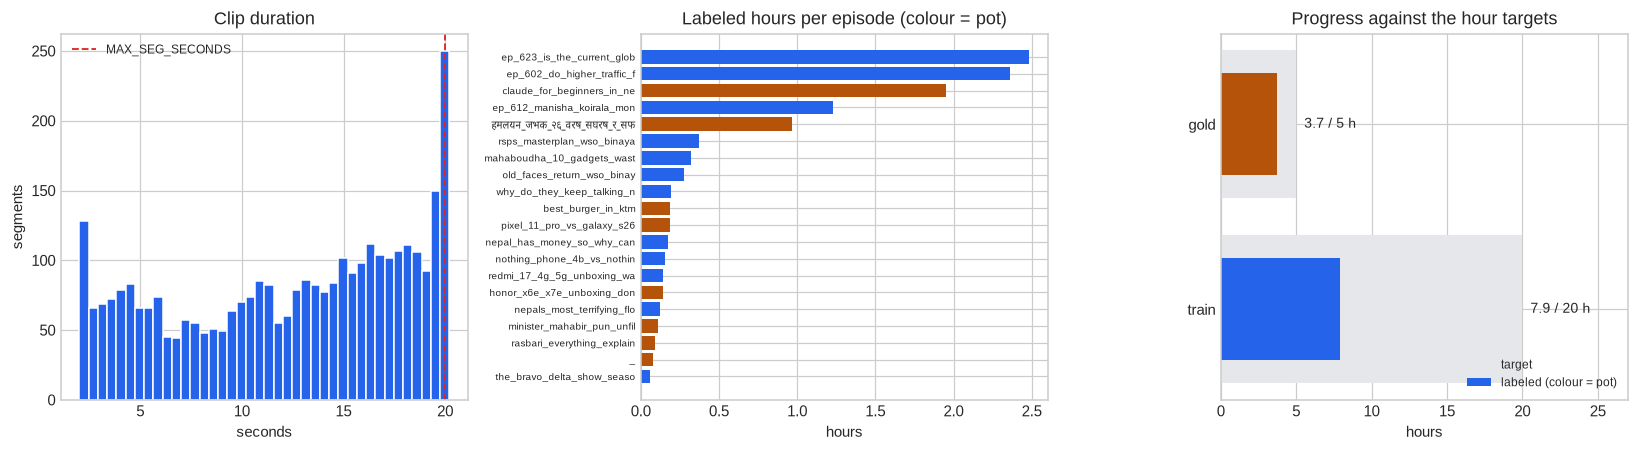

In [6]:
episodes = (
    seg.groupby("episode_id")
    .agg(
        pot=("pot", "first"),
        split=("split", "first"),
        genre=("genre", "first"),
        topic=("topic", "first"),
        n_speakers=("n_speakers", "first"),
        gender_mix=("gender_mix", "first"),
        age_mix=("age_mix", "first"),
        segments=("hours", "size"),
        hours=("hours", "sum"),
        edit_rate_pct=("is_edited", lambda s: 100 * s.mean()),
        screened_pct=("is_screened", lambda s: 100 * s.mean()),
        mean_cmi_pct=("cmi_pct", "mean"),
    )
    .sort_values("hours", ascending=False)
)
display(episodes)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

axes[0].hist(seg["duration_seconds"].dropna(), bins=40, color="#2563eb", edgecolor="white")
axes[0].axvline(20.0, color="#dc2626", ls="--", lw=1.2, label="MAX_SEG_SECONDS")
axes[0].set(title="Clip duration", xlabel="seconds", ylabel="segments")
axes[0].legend(fontsize=8)

order = episodes.sort_values("hours")
axes[1].barh(
    range(len(order)),
    order["hours"],
    color=[POT_COLOR.get(p, "#9ca3af") for p in order["pot"]],
)
axes[1].set_yticks(range(len(order)))
script_aware_ticklabels(axes[1], "y", [e[:26] for e in order.index], fontsize=6.5)
axes[1].set(title="Labeled hours per episode (colour = pot)", xlabel="hours")

pot_hours = by_pot["hours"].reindex(["train", "gold"]).fillna(0)
pot_target = by_pot["target_hours"].reindex(["train", "gold"]).fillna(0)
ypos = np.arange(len(pot_hours))
axes[2].barh(ypos, pot_target, color="#e5e7eb", label="target")
axes[2].barh(ypos, pot_hours, height=0.55,
             color=[POT_COLOR.get(p, "#9ca3af") for p in pot_hours.index], label="labeled")
for y, (have, want) in enumerate(zip(pot_hours, pot_target)):
    axes[2].text(want, y, f"  {have:.1f} / {want:.0f} h", va="center", fontsize=9)
axes[2].set_yticks(ypos)
axes[2].set_yticklabels(pot_hours.index)
axes[2].set(title="Progress against the hour targets", xlabel="hours")
axes[2].set_xlim(0, float(pot_target.max()) * 1.35)
axes[2].legend(["target", "labeled (colour = pot)"], fontsize=8, loc="lower right")

save_fig(fig, "01_corpus_shape")
plt.show()

## 5. What labeling actually did

Three numbers matter here and they are easy to conflate:

- **disposition** — what the annotator decided (`accepted_unchanged`, `edited`, `uncertain`).
- **verification_tier** — how hard they looked. `verified` means played and read; `screened` means
  accepted on the cross-ASR disagreement signal without listening. A screened row is a weaker claim
  and the gold export refuses to contain one at all (D63).
- **edit rate** — the share of segments the seed hypothesis got wrong enough to be corrected. This
  is the ceiling on auto-approval: no amount of ranking can push the auto-approved share above
  `1 - edit_rate` without approving segments a human would have edited.

verification_tier,screened,verified,All
disposition,,,
accepted_unchanged,836,1864,2700
edited,0,670,670
uncertain,0,5,5
All,836,2539,3375


Base edit rate, all rows      : 19.9%
Base edit rate, verified only : 26.4%  (n=2,539) — the honest figure; screened rows were never listened to,
                                so their 'accepted' is not evidence the hypothesis was right.
Screened share of the corpus  : 24.8%

Auto-approval ceiling implied by the verified edit rate: 73.6% of the queue.


segments  hours  edit_rate_pct
pot   verification_tier                                
gold  verified               1057 3.7072        25.6386
train screened                836 2.8655         0.0000
      verified               1482 5.0101        26.9231

  figure -> notebooks/figures/eda_02_labeling_process.png


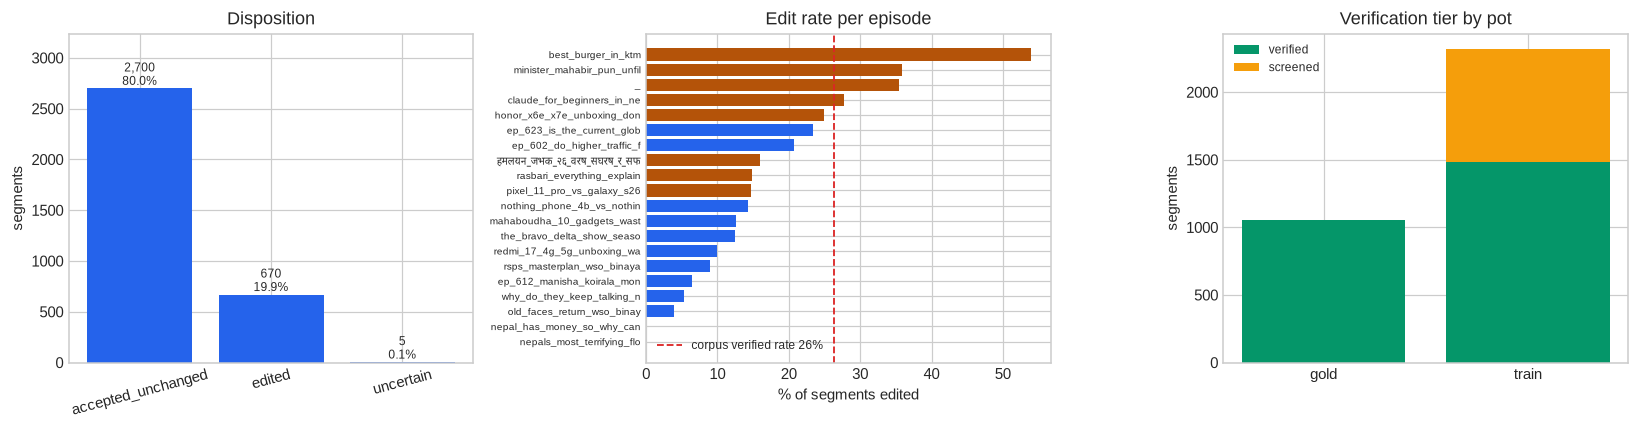

In [7]:
crosstab = pd.crosstab(seg["disposition"], seg["verification_tier"], margins=True)
display(crosstab)

base_edit_rate = seg["is_edited"].mean()
verified = seg[seg["verification_tier"] == "verified"]
verified_edit_rate = verified["is_edited"].mean()

print(f"Base edit rate, all rows      : {100 * base_edit_rate:.1f}%")
print(f"Base edit rate, verified only : {100 * verified_edit_rate:.1f}%  "
      f"(n={len(verified):,}) — the honest figure; screened rows were never listened to,")
print(f"{'':32}so their 'accepted' is not evidence the hypothesis was right.")
print(f"Screened share of the corpus  : {100 * seg['is_screened'].mean():.1f}%")
print()
print(f"Auto-approval ceiling implied by the verified edit rate: "
      f"{100 * (1 - verified_edit_rate):.1f}% of the queue.")

by_tier = seg.groupby(["pot", "verification_tier"]).agg(
    segments=("is_edited", "size"),
    hours=("hours", "sum"),
    edit_rate_pct=("is_edited", lambda s: 100 * s.mean()),
)
display(by_tier)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

disp_counts = seg["disposition"].value_counts()
axes[0].bar(disp_counts.index, disp_counts.values, color="#2563eb")
for x, v in enumerate(disp_counts.values):
    axes[0].text(x, v, f"{v:,}\n{100 * v / len(seg):.1f}%", ha="center", va="bottom", fontsize=8)
axes[0].set(title="Disposition", ylabel="segments")
axes[0].tick_params(axis="x", labelrotation=15)
axes[0].set_ylim(0, disp_counts.max() * 1.2)

ep_order = episodes.sort_values("edit_rate_pct")
axes[1].barh(range(len(ep_order)), ep_order["edit_rate_pct"],
             color=[POT_COLOR.get(p, "#9ca3af") for p in ep_order["pot"]])
axes[1].axvline(100 * verified_edit_rate, color="#dc2626", ls="--", lw=1.2,
                label=f"corpus verified rate {100 * verified_edit_rate:.0f}%")
axes[1].set_yticks(range(len(ep_order)))
script_aware_ticklabels(axes[1], "y", [e[:26] for e in ep_order.index], fontsize=6.5)
axes[1].set(title="Edit rate per episode", xlabel="% of segments edited")
axes[1].legend(fontsize=8)

tiers = seg.groupby(["pot", "verification_tier"]).size().unstack(fill_value=0)
bottom = np.zeros(len(tiers))
for tier, color in [("verified", "#059669"), ("screened", "#f59e0b")]:
    if tier in tiers:
        axes[2].bar(tiers.index, tiers[tier], bottom=bottom, label=tier, color=color)
        bottom = bottom + tiers[tier].values
axes[2].set(title="Verification tier by pot", ylabel="segments")
axes[2].legend(fontsize=8)

save_fig(fig, "02_labeling_process")
plt.show()

## 6. Code-mixing, measured two ways

`code_switch_density` is computed by the harness at import time on the **primary** hypothesis. The
human reference text is the better surface to measure on, so this section recomputes the mix from
the labeled transcripts directly and compares.

The token-level pass — script classification, the Code-Mixing Index per segment, and the English
insertion lexicon — runs over every reference transcript in parallel; each worker returns its own
counters and per-segment vector, and the reduction is a sum.

$$\mathrm{CMI} = 100 \times \frac{N - \max(N_{\mathrm{ne}}, N_{\mathrm{en}})}{N}$$

with $N$ the count of non-numeric tokens. A monolingual segment scores 0; a perfectly balanced
one scores 50.

In [8]:
DEV_RE = re.compile(r"[\u0900-\u097F]")
TOK_RE = re.compile(r"[A-Za-z']+|[\u0900-\u097F]+|\d+")
PUNCT_RE = re.compile(r"[.,!?;:\'\"|\u0964\u0965()\[\]{}\u2014-]")


def normalize_for_eval(text):
    """NFKC, strip punctuation, lowercase Latin, keep Devanagari as written."""
    if not text:
        return ""
    text = unicodedata.normalize("NFKC", text)
    text = PUNCT_RE.sub(" ", text)
    return " ".join(t if DEV_RE.search(t) else t.lower() for t in text.split())


def profile_texts(texts):
    """Token-level script profile for a block of transcripts. Returns per-text rows and counters."""
    rows = []
    latin, dev = Counter(), Counter()
    for text in texts:
        tokens = TOK_RE.findall(unicodedata.normalize("NFKC", text or ""))
        n_dev = n_latin = n_num = 0
        for token in tokens:
            if token.isdigit():
                n_num += 1
            elif DEV_RE.search(token):
                n_dev += 1
                dev[token] += 1
            else:
                n_latin += 1
                latin[token.lower()] += 1
        n_lang = n_dev + n_latin
        cmi = 100.0 * (n_lang - max(n_dev, n_latin)) / n_lang if n_lang else 0.0
        rows.append((len(tokens), n_dev, n_latin, n_num, cmi))
    return rows, latin, dev


def blocks(values, n):
    """Split a sequence into n contiguous blocks, preserving order."""
    edges = np.linspace(0, len(values), n + 1).astype(int)
    return [values[edges[i]: edges[i + 1]] for i in range(n) if edges[i + 1] > edges[i]]


texts = seg["text"].tolist()
t0 = time.perf_counter()
results = POOL(delayed(profile_texts)(block) for block in blocks(texts, N_JOBS))
parallel_seconds = time.perf_counter() - t0
t0 = time.perf_counter()
profile_texts(texts)
serial_seconds = time.perf_counter() - t0
timed("token profile", parallel_seconds,
      f"{len(texts):,} transcripts over {N_JOBS} workers; serial {serial_seconds:.2f}s "
      f"({serial_seconds / parallel_seconds:.1f}x)")

rows = [row for part in results for row in part[0]]
LATIN_VOCAB = Counter()
DEV_VOCAB = Counter()
for _, latin, dev in results:
    LATIN_VOCAB.update(latin)
    DEV_VOCAB.update(dev)

seg[["n_tokens", "n_dev", "n_latin", "n_numeric", "cmi_ref"]] = pd.DataFrame(
    rows, index=seg.index, columns=["n_tokens", "n_dev", "n_latin", "n_numeric", "cmi_ref"]
)
seg["latin_share_pct"] = 100 * seg["n_latin"] / seg[["n_dev", "n_latin"]].sum(axis=1).replace(0, np.nan)

total_tokens = int(seg["n_tokens"].sum())
print(f"Reference transcripts: {total_tokens:,} tokens "
      f"({int(seg['n_dev'].sum()):,} Devanagari, {int(seg['n_latin'].sum()):,} Latin, "
      f"{int(seg['n_numeric'].sum()):,} numeric)")
print(f"Latin token share      : {100 * seg['n_latin'].sum() / (seg['n_dev'].sum() + seg['n_latin'].sum()):.1f}%")
print(f"Vocabulary             : {len(DEV_VOCAB):,} Devanagari types, {len(LATIN_VOCAB):,} Latin types")
print()
print(f"CMI from the reference : mean {seg['cmi_ref'].mean():.1f}, median {seg['cmi_ref'].median():.1f}")
print(f"CMI stored at import   : mean {seg['cmi_pct'].mean():.1f}, median {seg['cmi_pct'].median():.1f}")
corr = seg[["cmi_ref", "cmi_pct"]].corr().iloc[0, 1]
print(f"Correlation between the two: r = {corr:.3f}")
print()
print(f"Segments with no English at all: {100 * (seg['n_latin'] == 0).mean():.1f}%")
print(f"Segments above CMI 15 (real intra-sentential mixing): {100 * (seg['cmi_ref'] > 15).mean():.1f}%")

  [token profile] 0.01s — 3,375 transcripts over 16 workers; serial 0.04s (3.6x)
Reference transcripts: 116,070 tokens (74,026 Devanagari, 41,462 Latin, 582 numeric)
Latin token share      : 35.9%
Vocabulary             : 9,143 Devanagari types, 5,408 Latin types

CMI from the reference : mean 23.7, median 25.0
CMI stored at import   : mean 23.2, median 24.1
Correlation between the two: r = 0.954

Segments with no English at all: 6.0%
Segments above CMI 15 (real intra-sentential mixing): 70.3%


  figure -> notebooks/figures/eda_03_code_mixing.png


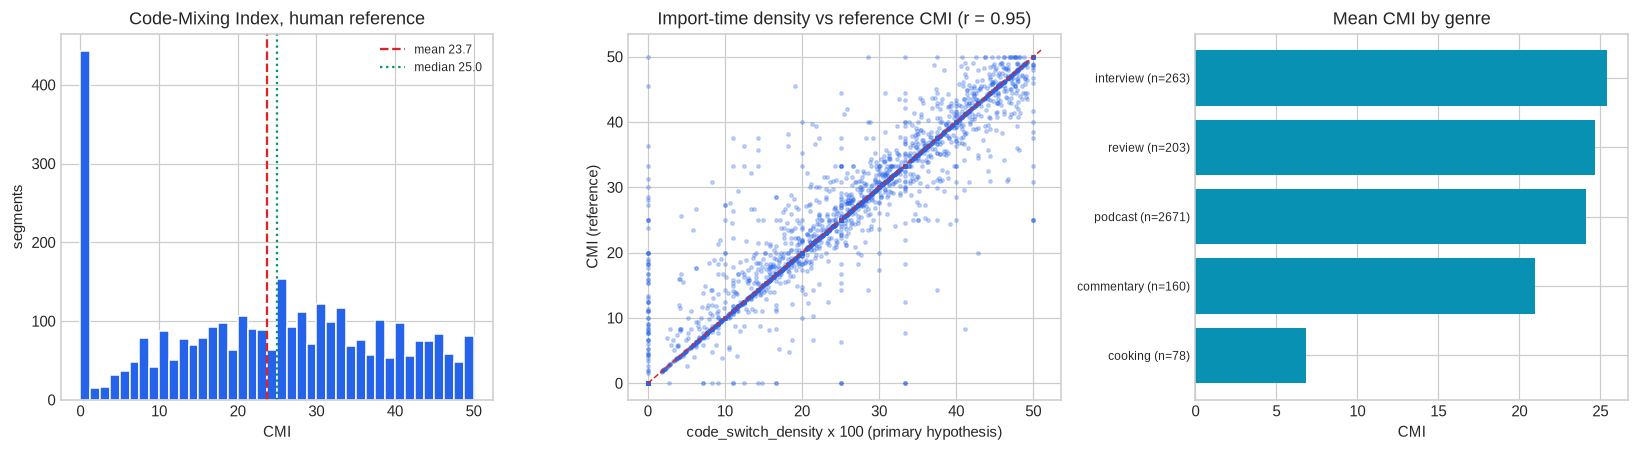

Most frequent English insertions in the human reference:


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29
token,i,the,so,and,a,to,of,is,you,it,like,that,we,in,this,are,uh,think,it's,for,one,phone,know,coffee,right,time,not,but,okay,was
count,840,727,642,558,519,515,507,492,491,421,309,306,296,259,257,242,224,212,198,189,189,186,184,180,171,168,168,163,162,160


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

axes[0].hist(seg["cmi_ref"], bins=40, color="#2563eb", edgecolor="white")
axes[0].axvline(seg["cmi_ref"].mean(), color="#dc2626", ls="--",
                label=f"mean {seg['cmi_ref'].mean():.1f}")
axes[0].axvline(seg["cmi_ref"].median(), color="#059669", ls=":",
                label=f"median {seg['cmi_ref'].median():.1f}")
axes[0].set(title="Code-Mixing Index, human reference", xlabel="CMI", ylabel="segments")
axes[0].legend(fontsize=8)

axes[1].scatter(seg["cmi_pct"], seg["cmi_ref"], s=5, alpha=0.25, color="#2563eb")
lims = [0, max(seg["cmi_pct"].max(), seg["cmi_ref"].max()) * 1.02]
axes[1].plot(lims, lims, color="#dc2626", lw=1, ls="--")
axes[1].set(title=f"Import-time density vs reference CMI (r = {corr:.2f})",
            xlabel="code_switch_density x 100 (primary hypothesis)", ylabel="CMI (reference)")

genre_cmi = seg.groupby("genre")["cmi_ref"].agg(["mean", "size"]).sort_values("mean")
axes[2].barh(range(len(genre_cmi)), genre_cmi["mean"], color="#0891b2")
axes[2].set_yticks(range(len(genre_cmi)))
axes[2].set_yticklabels([f"{g} (n={int(n)})" for g, n in zip(genre_cmi.index, genre_cmi["size"])],
                        fontsize=8)
axes[2].set(title="Mean CMI by genre", xlabel="CMI")

save_fig(fig, "03_code_mixing")
plt.show()

print("Most frequent English insertions in the human reference:")
display(pd.DataFrame(LATIN_VOCAB.most_common(30), columns=["token", "count"]).T)

## 7. Which strata are thin?

The gold pot is built to cover `show_id`, `gender`, `age_bracket` and `topic` before duration alone
decides what to take (D63/D69), and `min_stratum_hours` marks a stratum thin below 1.0 h. Speaker
demographics come from episode metadata; a stratum here is an *episode* attribute, so a single long
episode can make a stratum look healthy while resting on one voice — the speaker count is printed
alongside the hours for exactly that reason.

--- genre -------------------------------------------------------


,hours,segments,episodes,gold_hours,mean_cmi,edit_rate_pct,thin
genre,,,,,,,
podcast,8.7887,2671,9,2.3871,24.0951,21.5650,
interview,0.9693,263,1,0.9693,25.4352,15.9696,THIN
commentary,0.8599,160,4,0.0000,20.9765,5.0000,THIN
review,0.7978,203,4,0.1837,24.6529,12.8079,THIN
cooking,0.1671,78,2,0.1671,6.8185,23.0769,THIN


--- topic -------------------------------------------------------


,hours,segments,episodes,gold_hours,mean_cmi,edit_rate_pct,thin
topic,,,,,,,
news_current_affairs,2.6729,926,2,0.0000,22.7422,22.6782,
traffic_accidents,2.3622,636,1,0.0000,25.6570,20.7547,
ai,1.9492,551,1,1.9492,33.3605,27.7677,
personal_story,1.2274,390,1,0.0000,14.2062,6.4103,
business_owner,0.9693,263,1,0.9693,25.4352,15.9696,THIN
politics_governance,0.9331,203,4,0.1104,14.6590,13.3005,THIN
technology,0.7978,203,4,0.1837,24.6529,12.8079,THIN
travel_food,0.2615,81,2,0.2615,22.9605,46.9136,THIN
phone_review,0.1417,28,1,0.1417,35.8338,25.0000,THIN


--- gender_mix --------------------------------------------------


,hours,segments,episodes,gold_hours,mean_cmi,edit_rate_pct,thin
gender_mix,,,,,,,
male,9.1927,2652,11,3.2147,25.3555,22.2851,
mixed,1.6020,525,3,0.0000,16.9087,8.0000,
female,0.7882,198,6,0.4926,19.2939,18.6869,THIN


--- age_mix -----------------------------------------------------


,hours,segments,episodes,gold_hours,mean_cmi,edit_rate_pct,thin
age_mix,,,,,,,
mixed,6.2360,1991,5,0.1104,21.6166,19.4375,
20_39,4.2104,1043,12,2.4604,28.4564,21.3806,
40_59,1.0452,294,2,1.0452,23.5981,18.0272,


Strata under the 1.0 h floor:
  genre         4  ['interview', 'commentary', 'review', 'cooking']
  topic         8  ['business_owner', 'politics_governance', 'technology', 'travel_food', 'phone_review', 'natural_disaster', 'cooking', 'health_wellness']
  gender_mix    1  ['female']
  age_mix       0  []


  figure -> notebooks/figures/eda_04_stratum_coverage.png


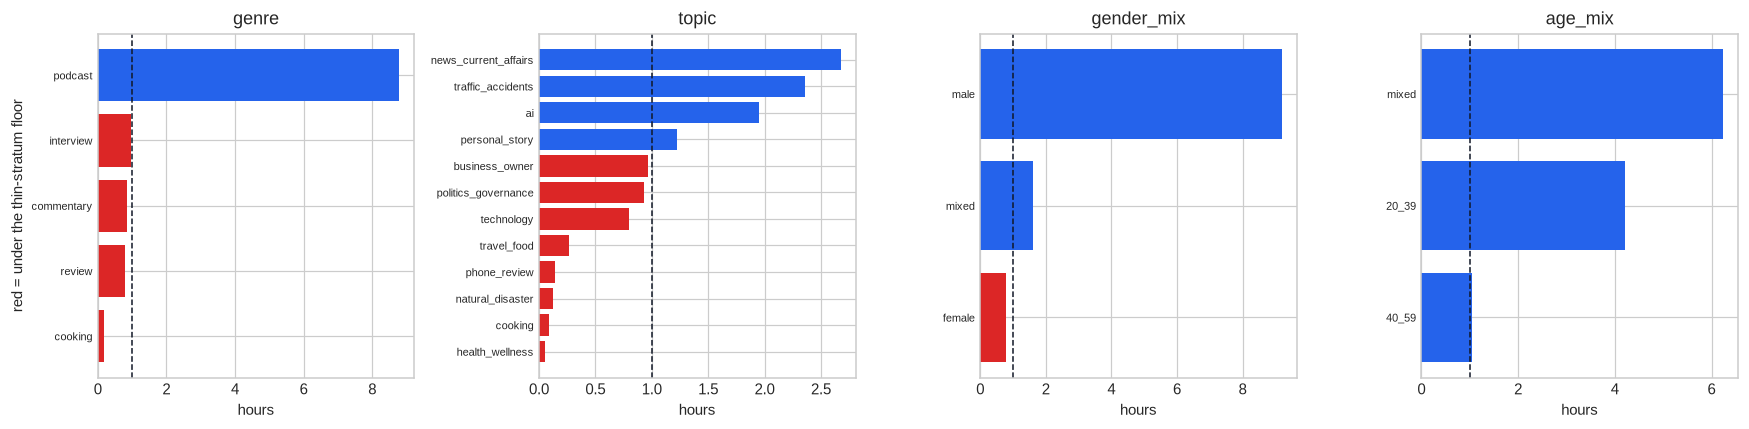

In [10]:
def stratum_table(key):
    """Hours, episodes and edit rate per level of one episode-level attribute."""
    table = (
        seg.groupby(key)
        .agg(
            hours=("hours", "sum"),
            segments=("hours", "size"),
            episodes=("episode_id", "nunique"),
            gold_hours=("hours", lambda s: seg.loc[s.index].query("pot == 'gold'")["hours"].sum()),
            mean_cmi=("cmi_ref", "mean"),
            edit_rate_pct=("is_edited", lambda s: 100 * s.mean()),
        )
        .sort_values("hours", ascending=False)
    )
    table["thin"] = np.where(table["hours"] < targets["min_stratum_hours"], "THIN", "")
    return table


COVERAGE_KEYS = ["genre", "topic", "gender_mix", "age_mix"]
for key in COVERAGE_KEYS:
    print(f"--- {key} " + "-" * (60 - len(key)))
    display(stratum_table(key))

thin = {
    key: stratum_table(key).query("thin == 'THIN'").index.tolist() for key in COVERAGE_KEYS
}
print(f"Strata under the {targets['min_stratum_hours']} h floor:")
for key, levels in thin.items():
    print(f"  {key:12s} {len(levels):2d}  {levels}")

fig, axes = plt.subplots(1, len(COVERAGE_KEYS), figsize=(4 * len(COVERAGE_KEYS), 4))
for ax, key in zip(axes, COVERAGE_KEYS):
    table = stratum_table(key).sort_values("hours")
    colors = ["#dc2626" if t == "THIN" else "#2563eb" for t in table["thin"]]
    ax.barh(range(len(table)), table["hours"], color=colors)
    ax.axvline(targets["min_stratum_hours"], color="#111827", ls="--", lw=1)
    ax.set_yticks(range(len(table)))
    ax.set_yticklabels([str(i)[:20] for i in table.index], fontsize=7.5)
    ax.set(title=key, xlabel="hours")
axes[0].set_ylabel("red = under the thin-stratum floor")
save_fig(fig, "04_stratum_coverage")
plt.show()

## 8. Multi-ASR benchmark against the human reference

Three systems transcribed every clip. The human label is the reference, so this is a real WER — on
2,300 train and 1,000 gold segments — rather than a proxy.

Two normalizations are reported, because the gap between them is itself informative:

- **raw** — the strings as written, punctuation and all.
- **normalized** — NFKC, punctuation stripped (including the Nepali danda `।`), Latin lowercased,
  Devanagari untouched. This is the fair comparison; the raw figure mostly measures who punctuates.

`Levenshtein` runs on token lists for WER and on characters for CER. Both, for three systems and
three cross-system pairs, over every segment, are computed in one parallel map.

**Read 8a before quoting any number from here.** The labels were seeded by one of the three
systems, which makes the naive per-system WER unusable as a comparison.

In [11]:
hyp_text = hyp.pivot_table(
    index="segment_id", columns="system_id", values="text", aggfunc="first"
).reindex(seg.index).fillna("")

PAIRS = [(a, b) for i, a in enumerate(SYSTEMS) for b in SYSTEMS[i + 1:]]


def score_block(items):
    """WER/CER of every system against the reference, plus pairwise cross-system distance."""
    out = []
    for segment_id, ref_raw, hyps in items:
        ref_norm = normalize_for_eval(ref_raw)
        ref_words = ref_norm.split()
        row = {
            "segment_id": segment_id,
            "ref_words": len(ref_words),
            "ref_chars": len(ref_norm),
        }
        normalized = {}
        for system, hyp_raw in hyps.items():
            hyp_norm = normalize_for_eval(hyp_raw)
            normalized[system] = hyp_norm
            hyp_words = hyp_norm.split()
            row[f"{system}|werr"] = Levenshtein.distance(ref_words, hyp_words)
            row[f"{system}|cerr"] = Levenshtein.distance(ref_norm, hyp_norm)
            row[f"{system}|werr_raw"] = Levenshtein.distance(
                (ref_raw or "").split(), (hyp_raw or "").split()
            )
            row[f"{system}|cerr_raw"] = Levenshtein.distance(ref_raw or "", hyp_raw or "")
            row[f"{system}|hyp_words"] = len(hyp_words)
        for left, right in PAIRS:
            a, b = normalized.get(left, "").split(), normalized.get(right, "").split()
            denominator = max(len(a), len(b))
            row[f"{left}~{right}|wdist"] = (
                Levenshtein.distance(a, b) / denominator if denominator else 0.0
            )
        out.append(row)
    return out


scorable = seg[seg["text"].str.len() > 0]
items = [
    (
        segment_id,
        scorable.at[segment_id, "text"],
        {s: (hyp_text.at[segment_id, s] if s in hyp_text.columns else "") or "" for s in SYSTEMS},
    )
    for segment_id in scorable.index
]

t0 = time.perf_counter()
scored = POOL(delayed(score_block)(block) for block in blocks(items, N_JOBS * 2))
parallel_seconds = time.perf_counter() - t0
t0 = time.perf_counter()
score_block(items)
serial_seconds = time.perf_counter() - t0
timed(
    "levenshtein",
    parallel_seconds,
    f"{len(items):,} segments x ({len(SYSTEMS)} systems + {len(PAIRS)} pairs), word and "
    f"character level; serial {serial_seconds:.2f}s ({serial_seconds / parallel_seconds:.1f}x)",
)

ev = pd.DataFrame([row for part in scored for row in part]).set_index("segment_id")
ev = ev.join(
    seg[["pot", "split", "disposition", "is_edited", "verification_tier", "seed_system_id",
         "cmi_ref", "duration_seconds", "word_disagreement_rate", "cer_between_hypotheses",
         "episode_id", "genre"]]
)
print(f"scored {len(ev):,} segments; {len(seg) - len(ev)} skipped for an empty reference")

  [levenshtein] 0.04s — 3,370 segments x (3 systems + 3 pairs), word and character level; serial 0.22s (5.3x)
scored 3,370 segments; 5 skipped for an empty reference


### 8a. The benchmark is contaminated by seeding — read both tables

Every segment reached the annotator pre-filled with **one** system's hypothesis. When the annotator
accepts unchanged, the label *is* that system's output, so its WER on those segments is zero by
construction. It is not a measurement. Scribe seeded roughly two thirds of the corpus, so the
naive table below flatters it heavily.

The honest comparison is **seed-excluded**: score each system only on the segments some *other*
system seeded. It is the same statistic, computed where the label was not written by the system
being scored. Both tables are printed; every headline number elsewhere in this notebook uses the
seed-excluded one.

In [12]:
def corpus_rates(frame, system):
    """Corpus-level (micro-averaged) WER and CER — total errors over total reference length."""
    if frame.empty or frame["ref_words"].sum() == 0:
        return {k: float("nan") for k in ("WER %", "CER %", "WER raw %", "CER raw %")}
    return {
        "WER %": 100 * frame[f"{system}|werr"].sum() / frame["ref_words"].sum(),
        "CER %": 100 * frame[f"{system}|cerr"].sum() / frame["ref_chars"].sum(),
        "WER raw %": 100 * frame[f"{system}|werr_raw"].sum() / frame["ref_words"].sum(),
        "CER raw %": 100 * frame[f"{system}|cerr_raw"].sum() / frame["ref_chars"].sum(),
    }


SCOPES = [
    ("all labeled", ev),
    ("gold (test)", ev[ev["pot"] == "gold"]),
    ("train", ev[ev["pot"] == "train"]),
    ("verified only", ev[ev["verification_tier"] == "verified"]),
]

naive_rows, excluded_rows = [], []
for scope, frame in SCOPES:
    if frame.empty:
        continue
    for system in SYSTEMS:
        naive_rows.append({"scope": scope, "system": system, "n": len(frame),
                           **corpus_rates(frame, system)})
        unseeded = frame[frame["seed_system_id"] != system]
        excluded_rows.append({"scope": scope, "system": system, "n": len(unseeded),
                              **corpus_rates(unseeded, system)})

bench_naive = pd.DataFrame(naive_rows).set_index(["scope", "system"])
bench = pd.DataFrame(excluded_rows).set_index(["scope", "system"])

print("AS LABELED — every system scored on every segment, including the ones it seeded.")
print("Not a fair comparison; kept only to show the size of the distortion.")
display(bench_naive)
print()
print("SEED-EXCLUDED — each system scored only where another system pre-filled the label.")
display(bench)

distortion = (bench["WER %"] - bench_naive["WER %"]).unstack()
print("WER points that seeding hides — how much lower the naive number is than the honest one:")
display(distortion)

AS LABELED — every system scored on every segment, including the ones it seeded.
Not a fair comparison; kept only to show the size of the distortion.


n   WER %   CER %  WER raw %  CER raw %
scope         system                                                          
all labeled   elevenlabs-scribe-v2  3370 10.3269  5.3226    12.8470     6.1428
              gemini-3.8-flash      3370 24.6527 12.8693    30.8974    14.7654
              mai-transcribe-2      3370 24.5303 13.9407    29.9359    16.0473
gold (test)   elevenlabs-scribe-v2  1057 16.3298  8.0753    20.8791     9.6017
              gemini-3.8-flash      1057 23.9036 12.5213    29.5544    14.4655
              mai-transcribe-2      1057 22.7921 12.9710    27.9186    14.9818
train         elevenlabs-scribe-v2  2313  7.1747  3.9176     8.6292     4.3774
              gemini-3.8-flash      2313 25.0460 13.0468    31.6026    14.9184
              mai-transcribe-2      2313 25.4430 14.4356    30.9951    16.5911
verified only elevenlabs-scribe-v2  2534 12.8078  6.5039    16.0926     7.5790
              gemini-3.8-flash      2534 24.5354 12.9811    30.5202    14.8831
              mai-transcribe-2      2534 24.1983 13.7252    29.4468    15.7973


SEED-EXCLUDED — each system scored only where another system pre-filled the label.


n   WER %   CER %  WER raw %  CER raw %
scope         system                                                          
all labeled   elevenlabs-scribe-v2  1087 23.2434 10.9745    30.3640    13.2732
              gemini-3.8-flash      2821 28.5827 14.5117    36.0577    16.7470
              mai-transcribe-2      2832 28.5063 15.9478    34.9905    18.4540
gold (test)   elevenlabs-scribe-v2   661 24.1440 11.5854    31.4609    14.0261
              gemini-3.8-flash       726 31.2179 15.5811    39.0630    18.2050
              mai-transcribe-2       727 29.6218 16.3170    36.8117    19.0833
train         elevenlabs-scribe-v2   426 21.8502 10.0570    28.6669    12.1425
              gemini-3.8-flash      2095 27.5269 14.0925    34.8535    16.1755
              mai-transcribe-2      2105 28.0490 15.8007    34.2439    18.2034
verified only elevenlabs-scribe-v2  1087 23.2434 10.9745    30.3640    13.2732
              gemini-3.8-flash      1985 29.9835 15.3174    37.6061    17.6967
              mai-transcribe-2      1996 29.6339 16.4743    36.3375    19.0963

WER points that seeding hides — how much lower the naive number is than the honest one:


system,elevenlabs-scribe-v2,gemini-3.8-flash,mai-transcribe-2
scope,,,
all labeled,12.9165,3.9301,3.9760
gold (test),7.8142,7.3143,6.8296
train,14.6755,2.4809,2.6060
verified only,10.4356,5.4481,5.4356


In [13]:
def bootstrap_wer(seed, errors, lengths, n_resamples):
    """Segment-level bootstrap of a micro-averaged rate; returns one array of resampled rates."""
    rng = np.random.default_rng(seed)
    n = len(errors)
    out = np.empty(n_resamples)
    for i in range(n_resamples):
        idx = rng.integers(0, n, n)
        out[i] = errors[idx].sum() / lengths[idx].sum()
    return out


N_BOOT = 4000
per_seed = max(1, N_BOOT // N_JOBS)
gold = ev[ev["pot"] == "gold"]
gold_unseeded = {s: gold[gold["seed_system_id"] != s] for s in SYSTEMS}

t0 = time.perf_counter()
boot_parts = POOL(
    delayed(bootstrap_wer)(
        1000 + seed,
        gold_unseeded[system][f"{system}|werr"].to_numpy(),
        gold_unseeded[system]["ref_words"].to_numpy(),
        per_seed,
    )
    for system in SYSTEMS
    for seed in range(N_JOBS)
)
timed("bootstrap", time.perf_counter() - t0,
      f"{len(SYSTEMS)} systems x {per_seed * N_JOBS:,} resamples of the seed-excluded gold pool")

ci_rows = []
for index, system in enumerate(SYSTEMS):
    draws = np.concatenate(boot_parts[index * N_JOBS:(index + 1) * N_JOBS]) * 100
    lo, hi = np.percentile(draws, [2.5, 97.5])
    ci_rows.append({"system": system, "n": len(gold_unseeded[system]), "gold WER %": draws.mean(),
                    "95% CI low": lo, "95% CI high": hi, "+/-": (hi - lo) / 2})
ci = pd.DataFrame(ci_rows).set_index("system")
print("Gold WER, seed-excluded, with a segment-level bootstrap interval:")
display(ci)

leader = ci["gold WER %"].idxmin()
runner_up = ci["gold WER %"].drop(leader).idxmin()
separated = ci.loc[leader, "95% CI high"] < ci.loc[runner_up, "95% CI low"]
print(f"Best on gold: {leader}. Its interval "
      f"{'does not overlap' if separated else 'overlaps'} the runner-up "
      f"({runner_up}) — the ordering is "
      f"{'resolved' if separated else 'NOT resolved'} at this corpus size.")

print()
print("Cross-system distance (normalized word level, all labeled segments) — this is the")
print("disagreement signal the queue is scored on, measured directly:")
display(ev[[f"{a}~{b}|wdist" for a, b in PAIRS]].describe().T[["mean", "50%", "std", "max"]])

  [bootstrap] 0.02s — 3 systems x 4,000 resamples of the seed-excluded gold pool
Gold WER, seed-excluded, with a segment-level bootstrap interval:


,n,gold WER %,95% CI low,95% CI high,+/-
system,,,,,
elevenlabs-scribe-v2,661,24.1454,22.9905,25.3475,1.1785
gemini-3.8-flash,726,31.2170,29.9336,32.5525,1.3095
mai-transcribe-2,727,29.6207,27.8652,31.4055,1.7702


Best on gold: elevenlabs-scribe-v2. Its interval does not overlap the runner-up (mai-transcribe-2) — the ordering is resolved at this corpus size.

Cross-system distance (normalized word level, all labeled segments) — this is the
disagreement signal the queue is scored on, measured directly:


,mean,50%,std,max
elevenlabs-scribe-v2~gemini-3.8-flash|wdist,0.3012,0.2836,0.1703,1.0000
elevenlabs-scribe-v2~mai-transcribe-2|wdist,0.3093,0.2453,0.2402,1.0000
gemini-3.8-flash~mai-transcribe-2|wdist,0.3445,0.2857,0.2366,1.0000


### 8b. Where the errors are: WER by code-switching density

If WER is flat across CMI tiers, the corpus is not buying anything a monolingual Nepali set would
not. If it climbs, the code-switched segments are the ones carrying the signal — and they are the
ones worth spending annotation time on. Seed-excluded throughout, for the reason above.

,segments,hours,edit_rate %,elevenlabs WER %,gemini WER %,mai WER %,min n
cmi_tier,,,,,,,
none (0-5),503,1.2512,10.1392,14.5366,19.4692,59.5012,131
light (5-15),494,1.6346,20.8502,22.5047,26.0786,26.2048,135
moderate (15-35),1519,5.4930,21.8565,24.2797,29.5232,24.6846,480
dense (>35),854,3.1995,21.5457,23.9768,31.6633,24.2117,341


  figure -> notebooks/figures/eda_05_asr_benchmark.png


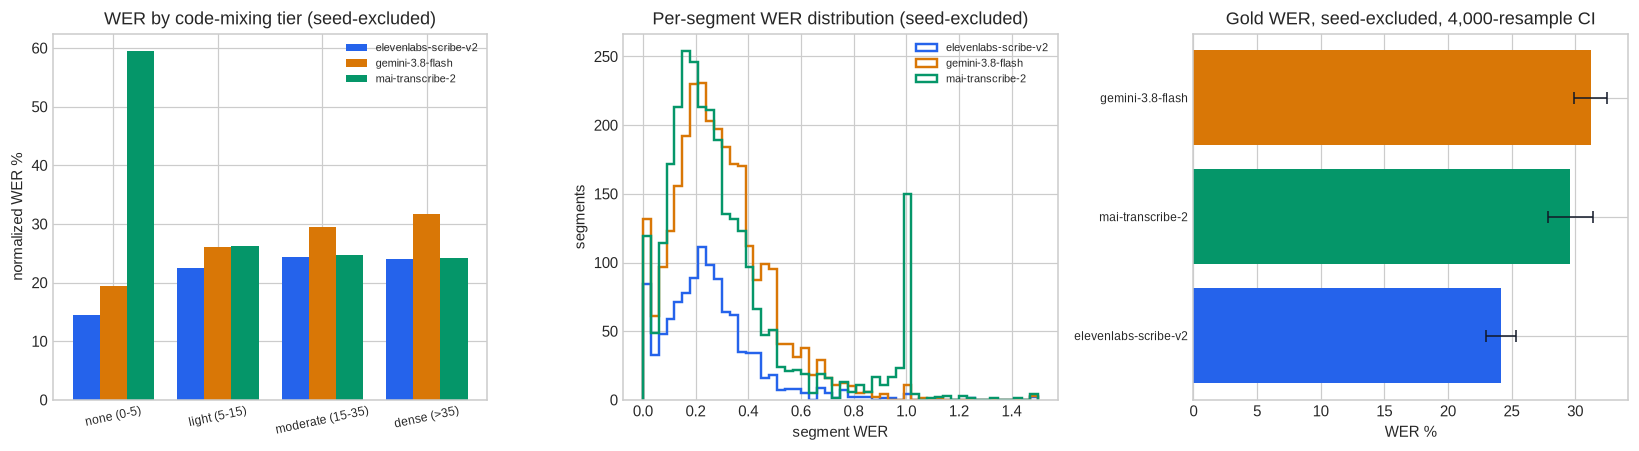

In [14]:
ev["cmi_tier"] = pd.cut(
    ev["cmi_ref"],
    bins=[-0.01, 5, 15, 35, 100],
    labels=["none (0-5)", "light (5-15)", "moderate (15-35)", "dense (>35)"],
)

SHORT = {s: s.split("-")[0] for s in SYSTEMS}
tier_rows = []
for tier, frame in ev.groupby("cmi_tier", observed=True):
    row = {"cmi_tier": tier, "segments": len(frame),
           "hours": frame["duration_seconds"].sum() / 3600,
           "edit_rate %": 100 * frame["is_edited"].mean()}
    smallest = len(frame)
    for system in SYSTEMS:
        unseeded = frame[frame["seed_system_id"] != system]
        smallest = min(smallest, len(unseeded))
        row[f"{SHORT[system]} WER %"] = corpus_rates(unseeded, system)["WER %"]
    # The seed-excluded pools differ per system; the smallest is what a tier's numbers rest on.
    row["min n"] = smallest
    tier_rows.append(row)
tier_table = pd.DataFrame(tier_rows).set_index("cmi_tier")
display(tier_table)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

x = np.arange(len(tier_table))
width = 0.26
for i, system in enumerate(SYSTEMS):
    axes[0].bar(x + (i - 1) * width, tier_table[f"{SHORT[system]} WER %"], width,
                label=system, color=SYS_COLOR[system])
axes[0].set_xticks(x)
axes[0].set_xticklabels(tier_table.index, fontsize=8, rotation=12)
axes[0].set(title="WER by code-mixing tier (seed-excluded)", ylabel="normalized WER %")
axes[0].legend(fontsize=7)

for system in SYSTEMS:
    unseeded = ev[ev["seed_system_id"] != system]
    rate = (unseeded[f"{system}|werr"] / unseeded["ref_words"].replace(0, np.nan)).clip(0, 1.5)
    axes[1].hist(rate.dropna(), bins=50, histtype="step", lw=1.6, label=system,
                 color=SYS_COLOR[system])
axes[1].set(title="Per-segment WER distribution (seed-excluded)", xlabel="segment WER",
            ylabel="segments")
axes[1].legend(fontsize=7)

ci_sorted = ci.sort_values("gold WER %")
axes[2].barh(range(len(ci_sorted)), ci_sorted["gold WER %"],
             xerr=ci_sorted["+/-"], color=[SYS_COLOR[s] for s in ci_sorted.index],
             error_kw={"ecolor": "#111827", "capsize": 4, "lw": 1})
axes[2].set_yticks(range(len(ci_sorted)))
axes[2].set_yticklabels(ci_sorted.index, fontsize=8)
axes[2].set(title=f"Gold WER, seed-excluded, {N_BOOT:,}-resample CI", xlabel="WER %")

save_fig(fig, "05_asr_benchmark")
plt.show()

## 9. Does cross-ASR disagreement predict a human edit?

This is the load-bearing question for the queue. If disagreement ranks segments well, a threshold
can auto-approve the quiet tail and spend annotator time on the noisy head.

**The analysis must exclude screened rows.** A screened row was accepted *because* its disagreement
was low — scoring the signal on rows it selected would be measuring the selection rule against
itself. Everything below runs on `verified` rows only, where a human listened regardless of what
the signal said.

Two separate things are then worth reading apart:

- **Ranking quality** (AUC) — can the signal order segments by whether they need an edit?
- **The achievable ceiling** — set by the base edit rate, not by the ranking. Auto-approving a
  share *c* of the queue admits at least `c - (1 - base_edit_rate)` edited segments once *c* passes
  `1 - base_edit_rate`, no matter how good the ordering is.

In [15]:
signal_frame = ev[ev["verification_tier"] == "verified"].copy()
signal_frame["measured_disagreement"] = signal_frame[
    [f"{a}~{b}|wdist" for a, b in PAIRS]
].mean(axis=1)

CANDIDATES = {
    "word_disagreement_rate (stored)": "word_disagreement_rate",
    "cer_between_hypotheses (stored)": "cer_between_hypotheses",
    "mean pairwise word distance (measured here)": "measured_disagreement",
    "reference CMI": "cmi_ref",
    "clip duration": "duration_seconds",
}

y = signal_frame["is_edited"].to_numpy()
base_rate = y.mean()


def auc(labels, scores):
    """Mann-Whitney AUC with tie-corrected ranks; NaN scores are treated as the minimum."""
    scores = np.nan_to_num(np.asarray(scores, dtype=float), nan=np.nanmin(scores))
    ranks = st.rankdata(scores)
    n_pos = labels.sum()
    n_neg = len(labels) - n_pos
    if n_pos == 0 or n_neg == 0:
        return float("nan")
    return (ranks[labels == 1].sum() - n_pos * (n_pos + 1) / 2) / (n_pos * n_neg)


def bootstrap_auc(seed, labels, scores, n_resamples):
    """Resample segments and recompute AUC; returns one array of AUCs."""
    rng = np.random.default_rng(seed)
    n = len(labels)
    out = np.empty(n_resamples)
    for i in range(n_resamples):
        idx = rng.integers(0, n, n)
        out[i] = auc(labels[idx], scores[idx])
    return out


t0 = time.perf_counter()
auc_parts = POOL(
    delayed(bootstrap_auc)(
        2000 + seed,
        y,
        np.nan_to_num(signal_frame[column].to_numpy(dtype=float)),
        max(1, 1200 // N_JOBS),
    )
    for column in CANDIDATES.values()
    for seed in range(N_JOBS)
)
timed("auc bootstrap", time.perf_counter() - t0,
      f"{len(CANDIDATES)} candidate signals x {max(1, 1200 // N_JOBS) * N_JOBS:,} resamples")

auc_rows = []
for index, (label, column) in enumerate(CANDIDATES.items()):
    draws = np.concatenate(auc_parts[index * N_JOBS:(index + 1) * N_JOBS])
    lo, hi = np.percentile(draws, [2.5, 97.5])
    auc_rows.append({
        "signal": label,
        "AUC": auc(y, signal_frame[column].to_numpy(dtype=float)),
        "95% CI low": lo,
        "95% CI high": hi,
        "beats chance": "yes" if lo > 0.5 else "no",
    })
auc_table = pd.DataFrame(auc_rows).set_index("signal").sort_values("AUC", ascending=False)

print(f"Verified segments        : {len(signal_frame):,}")
print(f"Base edit rate (verified): {100 * base_rate:.1f}%")
print(f"Perfect-ranking ceiling  : {100 * (1 - base_rate):.1f}% of the queue can be auto-approved")
print(f"{'':27}with zero edited segments admitted.")
display(auc_table)

  [auc bootstrap] 0.56s — 5 candidate signals x 1,200 resamples
Verified segments        : 2,534
Base edit rate (verified): 26.4%
Perfect-ranking ceiling  : 73.6% of the queue can be auto-approved
                           with zero edited segments admitted.


,AUC,95% CI low,95% CI high,beats chance
signal,,,,
mean pairwise word distance (measured here),0.6558,0.6331,0.6778,yes
word_disagreement_rate (stored),0.6367,0.6132,0.6583,yes
cer_between_hypotheses (stored),0.6242,0.6010,0.6480,yes
reference CMI,0.5202,0.4970,0.5447,no
clip duration,0.4838,0.4581,0.5078,no


Ranking by: mean pairwise word distance (measured here)

Auto-approve the quietest X% of the queue and this is what slips through:


,segments,edited admitted,leak rate %,leak with perfect ranking %,human effort saved %
auto-approved %,,,,,
30.0000,760,89,11.7105,0.0000,30.0000
50.0000,1267,220,17.3639,0.0000,50.0000
60.0000,1520,294,19.3421,0.0000,60.0000
70.0000,1773,374,21.0942,0.0000,70.0000
80.0000,2027,475,23.4336,8.0505,80.0000
90.0000,2280,594,26.0526,18.2671,90.0000


  figure -> notebooks/figures/eda_06_disagreement_gating.png


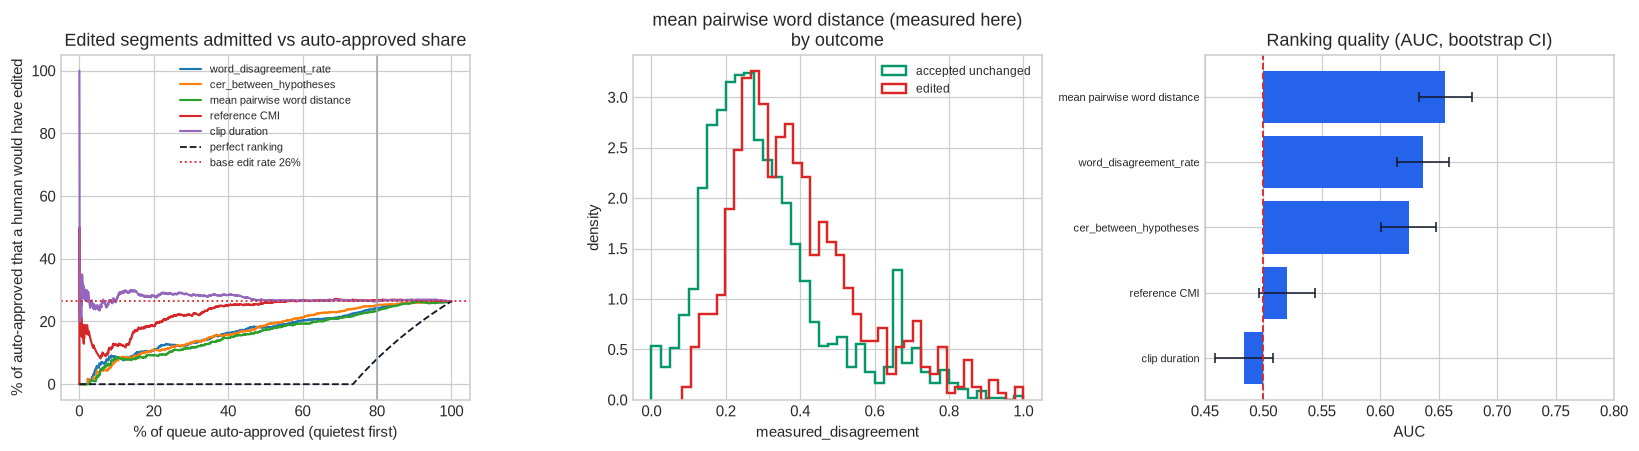

In [16]:
best_label, best_column = max(
    CANDIDATES.items(), key=lambda kv: auc_table.loc[kv[0], "AUC"]
)
scores = np.nan_to_num(signal_frame[best_column].to_numpy(dtype=float))
order = np.argsort(scores, kind="mergesort")  # quietest first
labels_sorted = y[order]

coverage = np.arange(1, len(labels_sorted) + 1) / len(labels_sorted)
admitted = np.cumsum(labels_sorted)  # edited segments wrongly auto-approved
leak_rate = admitted / np.arange(1, len(labels_sorted) + 1)

print(f"Ranking by: {best_label}")
print()
print("Auto-approve the quietest X% of the queue and this is what slips through:")
sweep_rows = []
for target in (0.3, 0.5, 0.6, 0.7, 0.8, 0.9):
    k = int(target * len(labels_sorted)) - 1
    perfect_leak = max(0.0, target - (1 - base_rate)) / target
    sweep_rows.append({
        "auto-approved %": 100 * target,
        "segments": k + 1,
        "edited admitted": int(admitted[k]),
        "leak rate %": 100 * leak_rate[k],
        "leak with perfect ranking %": 100 * perfect_leak,
        "human effort saved %": 100 * target,
    })
sweep = pd.DataFrame(sweep_rows).set_index("auto-approved %")
display(sweep)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

for label, column in CANDIDATES.items():
    s = np.nan_to_num(signal_frame[column].to_numpy(dtype=float))
    o = np.argsort(s, kind="mergesort")
    lk = np.cumsum(y[o]) / np.arange(1, len(y) + 1)
    axes[0].plot(100 * coverage, 100 * lk, lw=1.4, label=f"{label.split(' (')[0]}")
perfect = np.maximum(0.0, coverage - (1 - base_rate)) / coverage
axes[0].plot(100 * coverage, 100 * perfect, color="#111827", ls="--", lw=1.2,
             label="perfect ranking")
axes[0].axhline(100 * base_rate, color="#dc2626", ls=":", lw=1.2,
                label=f"base edit rate {100 * base_rate:.0f}%")
axes[0].axvline(80, color="#9ca3af", lw=1)
axes[0].set(title="Edited segments admitted vs auto-approved share",
            xlabel="% of queue auto-approved (quietest first)",
            ylabel="% of auto-approved that a human would have edited")
axes[0].legend(fontsize=7)

for edited, color, name in [(0, "#059669", "accepted unchanged"), (1, "#dc2626", "edited")]:
    subset = signal_frame.loc[signal_frame["is_edited"] == edited, best_column].dropna()
    axes[1].hist(subset, bins=40, density=True, histtype="step", lw=1.6, color=color, label=name)
axes[1].set(title=f"{best_label}\nby outcome", xlabel=best_column, ylabel="density")
axes[1].legend(fontsize=8)

auc_plot = auc_table.sort_values("AUC")
axes[2].barh(range(len(auc_plot)), auc_plot["AUC"] - 0.5, left=0.5,
             xerr=(auc_plot["95% CI high"] - auc_plot["95% CI low"]) / 2,
             color="#2563eb", error_kw={"ecolor": "#111827", "capsize": 3, "lw": 1})
axes[2].axvline(0.5, color="#dc2626", ls="--", lw=1.2)
axes[2].set_yticks(range(len(auc_plot)))
axes[2].set_yticklabels([i.split(" (")[0][:32] for i in auc_plot.index], fontsize=7.5)
axes[2].set(title="Ranking quality (AUC, bootstrap CI)", xlabel="AUC", xlim=(0.45, 0.8))

save_fig(fig, "06_disagreement_gating")
plt.show()

## 10. Seed-system anchoring

Section 8a established that a system's WER on the segments it seeded is *mechanically* near zero
whenever the annotator accepts unchanged — that is arithmetic, not bias, and it is why every
headline number here is seed-excluded.

The behavioural question is different and is what this section tests: **does the annotator work
differently depending on which system seeded them?** If one system's pre-fill is edited less often
than another's, the labels carry that system's habits, and the seed pools are not exchangeable — so
even the seed-excluded comparison is between subtly different populations of segments.

The test is the edit rate by seed system on verified rows, where a human listened regardless.

In [17]:
seed_rows = []
for system, frame in ev.groupby("seed_system_id"):
    verified_rows = frame[frame["verification_tier"] == "verified"]
    row = {
        "seed": system,
        "segments": len(frame),
        "share of corpus %": 100 * len(frame) / len(ev),
        "verified": len(verified_rows),
        "screened %": 100 * (frame["verification_tier"] == "screened").mean(),
        "verified edit rate %": 100 * verified_rows["is_edited"].mean(),
        "mean CMI": frame["cmi_ref"].mean(),
        "mean duration s": frame["duration_seconds"].mean(),
    }
    # How the *other two* systems score inside this seed pool: an unbiased read, because
    # neither of them wrote the label. Comparable across rows of this table.
    for other in SYSTEMS:
        row[f"WER% {other.split('-')[0]}"] = (
            float("nan")
            if other == system
            else 100 * frame[f"{other}|werr"].sum() / frame["ref_words"].sum()
        )
    seed_rows.append(row)
seed_table = pd.DataFrame(seed_rows).set_index("seed")
print("Blank WER cells are the seeded system itself — that number would be measuring the label.")
display(seed_table)

contingency = pd.crosstab(
    ev.loc[ev["verification_tier"] == "verified", "seed_system_id"],
    ev.loc[ev["verification_tier"] == "verified", "is_edited"],
)
if contingency.shape[0] > 1 and contingency.shape[1] > 1:
    chi2, pvalue, dof, _ = st.chi2_contingency(contingency)
    print(f"Edit rate vs seed system (verified rows): chi2 = {chi2:.2f}, dof = {dof}, p = {pvalue:.4f}")
    print("  -> " + ("edit rate depends on which system seeded the segment"
                     if pvalue < 0.05 else "no detectable anchoring effect at p < 0.05"))
else:
    print("Only one seed system present; anchoring cannot be tested from this export.")

# Are the seed pools exchangeable? If the pools differ in what they contain, a seed-excluded
# comparison across systems is still comparing different populations of audio.
pools = ev.groupby("seed_system_id")
print()
print("Are the three seed pools drawn from the same audio? A difference here means the")
print("seed-excluded WERs in section 8a are measured on populations that are not identical.")
pool_check = pools.agg(
    segments=("cmi_ref", "size"),
    mean_cmi=("cmi_ref", "mean"),
    mean_duration_s=("duration_seconds", "mean"),
    mean_disagreement=("word_disagreement_rate", "mean"),
    gold_share_pct=("pot", lambda p: 100 * (p == "gold").mean()),
)
display(pool_check)

groups = [g["cmi_ref"].dropna().to_numpy() for _, g in pools]
if len(groups) > 1:
    stat, pvalue = st.kruskal(*groups)
    print(f"CMI across seed pools: Kruskal-Wallis H = {stat:.2f}, p = {pvalue:.4f} -> "
          + ("pools differ in code-mixing density" if pvalue < 0.05
             else "no detectable difference in code-mixing density"))

print()
print("For completeness, the mechanical effect section 8a corrects for — a system's WER on the")
print("segments it seeded versus everywhere else. The gap is expected and is NOT evidence of")
print("bias; it is what accepting a hypothesis unchanged does to that hypothesis's WER.")
mechanical = pd.DataFrame(
    [
        {
            "system": system,
            "WER% where it seeded": 100
            * ev[ev["seed_system_id"] == system][f"{system}|werr"].sum()
            / max(ev[ev["seed_system_id"] == system]["ref_words"].sum(), 1),
            "WER% elsewhere (used above)": 100
            * ev[ev["seed_system_id"] != system][f"{system}|werr"].sum()
            / max(ev[ev["seed_system_id"] != system]["ref_words"].sum(), 1),
            "n seeded": int((ev["seed_system_id"] == system).sum()),
        }
        for system in SYSTEMS
    ]
).set_index("system")
display(mechanical)

Blank WER cells are the seeded system itself — that number would be measuring the label.


,segments,share of corpus %,verified,screened %,verified edit rate %,mean CMI,mean duration s,WER% elevenlabs,WER% gemini,WER% mai
seed,,,,,,,,,,
elevenlabs-scribe-v2,2283,67.7448,1447,36.6185,26.3303,22.6402,12.1671,NaN,28.5250,28.2645
gemini-3.8-flash,549,16.2908,549,0.0000,27.5046,25.1771,12.7078,24.7091,NaN,29.3871
mai-transcribe-2,538,15.9644,538,0.0000,25.6506,26.8220,12.8775,21.7262,28.8003,NaN


Edit rate vs seed system (verified rows): chi2 = 0.50, dof = 2, p = 0.7783
  -> no detectable anchoring effect at p < 0.05

Are the three seed pools drawn from the same audio? A difference here means the
seed-excluded WERs in section 8a are measured on populations that are not identical.


,segments,mean_cmi,mean_duration_s,mean_disagreement,gold_share_pct
seed_system_id,,,,,
elevenlabs-scribe-v2,2283,22.6402,12.1671,0.3702,17.3456
gemini-3.8-flash,549,25.1771,12.7078,0.3562,60.2914
mai-transcribe-2,538,26.8220,12.8775,0.3464,61.3383


CMI across seed pools: Kruskal-Wallis H = 41.56, p = 0.0000 -> pools differ in code-mixing density

For completeness, the mechanical effect section 8a corrects for — a system's WER on the
segments it seeded versus everywhere else. The gap is expected and is NOT evidence of
bias; it is what accepting a hypothesis unchanged does to that hypothesis's WER.


,WER% where it seeded,WER% elsewhere (used above),n seeded
system,,,
elevenlabs-scribe-v2,3.3564,23.2434,2283
gemini-3.8-flash,6.5375,28.5827,549
mai-transcribe-2,5.4215,28.5063,538


## 11. Import-time flags, hypothesis shape, and word timings

The flags are set at import from all hypotheses, before anyone looks at the clip. Two questions:
do they predict an edit, and do they predict an *unusable* clip? A flag that fires often and
predicts nothing is queue noise.

The word arrays reduced during the parallel load are also profiled here. `word_span_seconds` is the
total time a hypothesis's words cover; far short of the clip duration is the shape of a transcript
that stopped early, which is what `missed_speech` is trying to catch.

,segments,% of corpus,edit rate when set %,edit rate when clear %,uncertain when set %,lift (pp)
flag,,,,,,
repeated_ngram,8,0.2370,37.5000,19.8099,0.0000,17.6901
script_conflict,355,10.5185,21.1268,19.7020,0.5634,1.4248
missed_speech,423,12.5333,17.4941,20.1897,0.2364,-2.6956


Segments with no flag at all: 79.9%


,hypotheses,words,empty_hypotheses,mean_words,words_per_second,mean_span_coverage,median_tail_gap_s,mean_word_conf
system_id,,,,,,,,
elevenlabs-scribe-v2,3375,113739,0,33.7004,2.7277,0.6693,0.2030,NaN
gemini-3.8-flash,3375,116020,0,34.3763,2.7824,0.6214,0.2410,0.5791
mai-transcribe-2,3375,114053,0,33.7935,2.7352,0.6324,0.1200,NaN


  figure -> notebooks/figures/eda_07_flags_and_word_timings.png


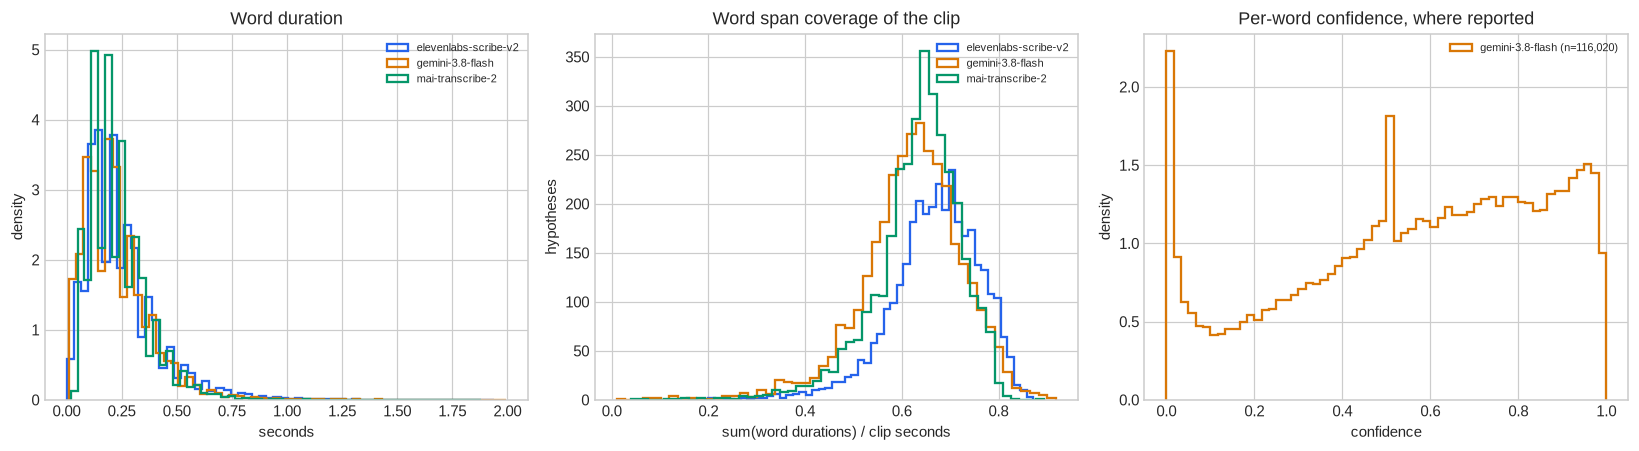

In [18]:
flag_columns = [c for c in seg.columns if c.startswith("flag_")]
flag_rows = []
for column in flag_columns:
    fired = seg[seg[column] == 1]
    quiet = seg[seg[column] == 0]
    flag_rows.append({
        "flag": column.removeprefix("flag_"),
        "segments": len(fired),
        "% of corpus": 100 * len(fired) / len(seg),
        "edit rate when set %": 100 * fired["is_edited"].mean() if len(fired) else np.nan,
        "edit rate when clear %": 100 * quiet["is_edited"].mean() if len(quiet) else np.nan,
        "uncertain when set %": 100 * (fired["disposition"] == "uncertain").mean() if len(fired) else np.nan,
    })
flag_table = pd.DataFrame(flag_rows).set_index("flag")
flag_table["lift (pp)"] = flag_table["edit rate when set %"] - flag_table["edit rate when clear %"]
display(flag_table.sort_values("lift (pp)", ascending=False))
print(f"Segments with no flag at all: {100 * (seg['n_flags'] == 0).mean():.1f}%")

hyp_shape = hyp.merge(
    seg[["duration_seconds", "is_edited", "pot"]], left_on="segment_id", right_index=True
)
hyp_shape["span_coverage"] = hyp_shape["word_span_seconds"] / hyp_shape["duration_seconds"]
hyp_shape["tail_gap_seconds"] = hyp_shape["duration_seconds"] - hyp_shape["last_word_end"]

shape_table = hyp_shape.groupby("system_id").agg(
    hypotheses=("n_words", "size"),
    words=("n_words", "sum"),
    empty_hypotheses=("n_words", lambda s: int((s == 0).sum())),
    mean_words=("n_words", "mean"),
    words_per_second=("n_words", lambda s: s.sum()),
    mean_span_coverage=("span_coverage", "mean"),
    median_tail_gap_s=("tail_gap_seconds", "median"),
    mean_word_conf=("mean_word_conf", "mean"),
)
shape_table["words_per_second"] = shape_table["words_per_second"] / seg["duration_seconds"].sum()
display(shape_table)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

for system in SYSTEMS:
    durations = WORD_DUR[system]
    axes[0].hist(durations[(durations > 0) & (durations < 2)], bins=60, density=True,
                 histtype="step", lw=1.5, color=SYS_COLOR[system], label=system)
axes[0].set(title="Word duration", xlabel="seconds", ylabel="density")
axes[0].legend(fontsize=7)

for system in SYSTEMS:
    subset = hyp_shape.loc[hyp_shape["system_id"] == system, "span_coverage"].clip(0, 1.2)
    axes[1].hist(subset.dropna(), bins=50, histtype="step", lw=1.5, color=SYS_COLOR[system],
                 label=system)
axes[1].set(title="Word span coverage of the clip", xlabel="sum(word durations) / clip seconds",
            ylabel="hypotheses")
axes[1].legend(fontsize=7)

confident = {s: v for s, v in WORD_CONF.items() if len(v)}
if confident:
    for system, values in confident.items():
        axes[2].hist(values, bins=60, density=True, histtype="step", lw=1.5,
                     color=SYS_COLOR[system], label=f"{system} (n={len(values):,})")
    axes[2].set(title="Per-word confidence, where reported", xlabel="confidence", ylabel="density")
    axes[2].legend(fontsize=7)
else:
    axes[2].axis("off")
    axes[2].set_title("No route reports per-word confidence")

save_fig(fig, "07_flags_and_word_timings")
plt.show()

## 12. What the corpus says

Everything below is read straight off the frames above — rerunning the notebook on a newer export
regenerates it.

In [19]:
gold_hours = float(by_pot.loc["gold", "hours"]) if "gold" in by_pot.index else 0.0
train_hours = float(by_pot.loc["train", "hours"]) if "train" in by_pot.index else 0.0
best_system = ci["gold WER %"].idxmin()
best_signal = auc_table["AUC"].idxmax()
best_auc = float(auc_table.loc[best_signal, "AUC"])
ceiling = 1 - base_rate

lines = [
    "SIZE",
    f"  {len(seg):,} labeled segments, {total_hours:.2f} h, {seg['episode_id'].nunique()} episodes.",
    f"  gold {gold_hours:.2f} h of {targets['gold_hours_target']:.0f} h target "
    f"({100 * gold_hours / targets['gold_hours_target']:.0f}%); "
    f"train {train_hours:.2f} h of {targets['train_hours_target']:.0f} h "
    f"({100 * train_hours / targets['train_hours_target']:.0f}%).",
    f"  Gold is {gold_share:.0f}% of the labeled corpus against a "
    f"{100 * targets['gold_max_corpus_fraction']:.0f}% cap.",
    "",
    "LABELING",
    f"  Verified edit rate {100 * base_rate:.1f}% -> auto-approval can never exceed "
    f"{100 * ceiling:.1f}% of the queue without admitting edited segments.",
    f"  {100 * seg['is_screened'].mean():.1f}% of rows were screened, not listened to; "
    f"they are excluded from every signal-quality number above.",
    "",
    "CODE-MIXING",
    f"  {100 * seg['n_latin'].sum() / (seg['n_dev'].sum() + seg['n_latin'].sum()):.1f}% of "
    f"reference tokens are Latin script; mean CMI {seg['cmi_ref'].mean():.1f}.",
    f"  {100 * (seg['n_latin'] == 0).mean():.1f}% of segments contain no English at all — "
    f"the monolingual share the corpus is paying for.",
    "",
    "ASR",
]
gold_bench = bench.loc["gold (test)"]
for system in ci.sort_values("gold WER %").index:
    lines.append(
        f"  {system:24s} gold WER {ci.loc[system, 'gold WER %']:5.1f}% "
        f"[{ci.loc[system, '95% CI low']:.1f}-{ci.loc[system, '95% CI high']:.1f}]  "
        f"CER {gold_bench.loc[system, 'CER %']:5.1f}%   (seed-excluded, n={int(ci.loc[system, 'n'])})"
    )
lines.append(f"  Best on gold: {best_system}"
             + ("; its interval is separated from the runner-up." if separated
                else "; the interval overlaps the runner-up, so the ordering is not resolved."))
lines.append(f"  Quoting the naive table instead would have understated its gold WER by "
             f"{distortion.loc['gold (test)', best_system]:.1f} points.")
lines += [
    "",
    "DISAGREEMENT AS A GATE",
    f"  Best ranking signal: {best_signal} at AUC {best_auc:.3f} "
    f"(95% CI {auc_table.loc[best_signal, '95% CI low']:.3f}"
    f"-{auc_table.loc[best_signal, '95% CI high']:.3f}).",
    f"  Auto-approving 80% of the queue admits "
    f"{sweep.loc[80.0, 'leak rate %']:.1f}% edited segments; even a perfect ranking admits "
    f"{sweep.loc[80.0, 'leak with perfect ranking %']:.1f}%.",
    "  The binding constraint is the base edit rate, not the ordering.",
    "",
    "THIN STRATA (under the "
    f"{targets['min_stratum_hours']} h floor)",
]
for key, levels in thin.items():
    if levels:
        lines.append(f"  {key}: {', '.join(str(v) for v in levels)}")
print("\n".join(lines))
print()
print("Figures written to notebooks/figures/:")
for path in sorted(FIG_DIR.glob("eda_*.png")):
    print(f"  {path.name}  ({path.stat().st_size / 1024:.0f} KB)")

SIZE
  3,375 labeled segments, 11.58 h, 20 episodes.
  gold 3.71 h of 5 h target (74%); train 7.88 h of 20 h (39%).
  Gold is 32% of the labeled corpus against a 35% cap.

LABELING
  Verified edit rate 26.4% -> auto-approval can never exceed 73.6% of the queue without admitting edited segments.
  24.8% of rows were screened, not listened to; they are excluded from every signal-quality number above.

CODE-MIXING
  35.9% of reference tokens are Latin script; mean CMI 23.7.
  6.0% of segments contain no English at all — the monolingual share the corpus is paying for.

ASR
  elevenlabs-scribe-v2     gold WER  24.1% [23.0-25.3]  CER  11.6%   (seed-excluded, n=661)
  mai-transcribe-2         gold WER  29.6% [27.9-31.4]  CER  16.3%   (seed-excluded, n=727)
  gemini-3.8-flash         gold WER  31.2% [29.9-32.6]  CER  15.6%   (seed-excluded, n=726)
  Best on gold: elevenlabs-scribe-v2; its interval is separated from the runner-up.
  Quoting the naive table instead would have understated its gol